In [1]:
import datetime
import http
import json
import pathlib
import re
import os
import subprocess
import sys

import cycler
from IPython.display import display, Markdown
import matplotlib.pyplot
import numpy
import polars
from tqdm.notebook import tqdm

EVALUATION_DIR = pathlib.Path.cwd() / "06_e2e_eval"

os.environ["EVALUATION_DIR"] = str(EVALUATION_DIR)

# End-to-end Validation

In [2]:
%load_ext jupyter_tikz

preamble = r"""
\usepackage{adjustbox}

\usepackage[T1]{fontenc}
\usepackage[tt=false, type1=true]{libertine}
\usepackage[varqu]{zi4}
\usepackage[libertine]{newtxmath}

\usepackage{tikz}

\usetikzlibrary{
  arrows.meta,
  calc,
  colorbrewer,
  decorations.pathreplacing,
  fit,
  positioning,
  shapes.geometric,
}
\pgfdeclarelayer{bg}
\pgfdeclarelayer{fg}
\pgfsetlayers{bg,main,fg}
\graphicspath{{06_e2e_eval/figs/}}
\newcommand{\inputexternaltikzpath}{06_e2e_eval/figs/}
"""

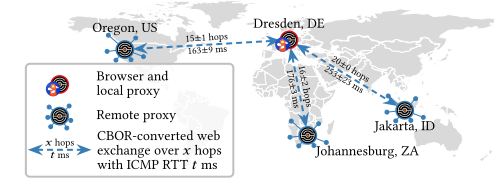

In [3]:
%%tikz -p "$preamble" -S "06_e2e_eval/figs/e2e-setup")
\adjustbox{scale=2}{\input{06_e2e_eval/figs/e2e-setup.tex}}

## Running the Experiments

##### Terminal 1 (on remote proxy host)

Prepare remote proxy.

```console
$ # Install docker compose, git, and we also recommend a terminal multiplexer like `screen` or `tmux`
$ # Clone this repository
$ # Checkout Component Referencing branch
$ git -C 04_cbor4dns_eval/cbor4dns checkout name-compr-str-ref
Previous HEAD position was d4c4441 decode: remove stray debug print
branch 'name-compr-str-ref' set up to track 'origin/name-compr-str-ref'.
Switched to a new branch 'name-compr-str-ref'
$ cd 06_e2e_eval
$ # Measure distance and RTT to remote proxy
$ script -fq output-dataset/traceroute-$(date "+%s").log \
  -c 'for r in $(seq 20); do traceroute "<remote proxy hostname or IPv4 address>"; done'
...
$ script -fq output-dataset/docker-compose-remote-$(date "+%s").log
$ ./start_remote_setup.sh up
...
 ✔ Network 06_e2e_eval_remote           Created                                                                                       0.1s
 ✔ Container 06_e2e_eval-remote-proxy-1 Created                                                                                       0.1s
Attaching to remote-proxy-1
```

##### Terminal 2 (on local proxy host)

Prepare local proxy. This only executes runs 1 to 5, for later runs, change `LIGHTHOUSE_RUNS_START` and `LIGHTHOUSE_RUNS`.
For instance, for runs 6 to 10, use `LIGHTHOUSE_RUNS_START=5` and `LIGHTHOUSE_RUNS=10`.
For the experiments documented in the paper we set `LIGHTHOUSE_LOG_EXTRA` to `-us-west` for Google Cloud Platform Region `us-west1` (Oregon, USA), `-africa-south` for `africa-south1` (Johannesburg, South Africa), and `-indonesia` for `asia-southeast2` (Jakarta, Indonesia).

```console
$ # Install docker compose, git, and we also recommend a terminal multiplexer like `screen` or `tmux`
$ Clone this directory
$ # checkout Component Referencing branch
$ git -C 04_cbor4dns_eval/cbor4dns checkout name-compr-str-ref
Previous HEAD position was d4c4441 decode: remove stray debug print
branch 'name-compr-str-ref' set up to track 'origin/name-compr-str-ref'.
Switched to a new branch 'name-compr-str-ref'
$ cd 06_e2e_eval
$ script -fq output-dataset/docker-compose-local-$(date "+%s").log
$ TRANCO_LOWER_LIMIT=0 TRANCO_UPPER_LIMIT=100 LIGHTHOUSE_RUNS_START=1 LIGHTHOUSE_RUNS=5 LIGHTHOUSE_LOG_EXTRA="<note on remote proxy, e.g. location>" PUID=$(id -u) PGID=$(id -g) PROXY_REMOTE_HOST="<remote proxy hostname or IPv4 address>" ./start_local_setup.sh up
...
lighthouse-1   | Updating certificates in /etc/ssl/certs...
lighthouse-1   | rehash: warning: skipping ca-certificates.crt, it does not contain exactly one certificate or CRL
lighthouse-1   | 1 added, 0 removed; done.
lighthouse-1   | Running hooks in /etc/ca-certificates/update.d...
lighthouse-1   | done.
lighthouse-1   | Please configure the local proxy and Chrome with the mitmproxy
lighthouse-1   | certificates. For the local proxy use docker `exec` with bash
lighthouse-1   | and configure them for a Debian system. For Chrome go to
lighthouse-1   | https://localhost:3001. See
lighthouse-1   | https://docs.mitmproxy.org/archive/v12/concepts/certificates/
lighthouse-1   | for how to do that. Set the DNS provider of Chrome to
lighthouse-1   | https://dns.google/dns-query and use docker `exec` to
lighthouse-1   | `touch ~/tls_configured`. The experiments will start
lighthouse-1   | shortly after. You can then close the https://localhost:3001 tab.
lighthouse-1   |
lighthouse-1   | DO NOT CLOSE CHROME WITHIN THAT TAB!
...
```

Change `LIGHTHOUSE_RUNS_START` and `LIGHTHOUSE_RUNS` to the next chunk (e.g., `LIGHTHOUSE_RUNS_START=6` and `LIGHTHOUSE_RUNS=10`) for staggered follow-up runs.

##### Terminal 3 (on local proxy host)

Add mitmproxy certificates of remote proxy in local proxy (you might need to configure your SSH public key with the remote proxy host first).

```console
$ cd 06_e2e_eval
$ rsync -avz "<remote proxy SSH user>@<remote proxy SSH host>:<path to repo on remote proxy>/06_e2e_eval/mitmproxy-remote/mitmproxy-ca-cert.pem mitmproxy-remote/"; ./start_local_setup.sh exec -ti local-proxy /app/update_certificate.sh /mitmproxy-remote/mitmproxy-ca-cert.pem
```

##### In Browser via https://localhost:3001 (on local proxy host)

For our experiments we used Chrome Version 147.0.7727.101.

<details>
<summary>Configure DoH for POST queries and add mitmproxy certificates of local proxy in browser.</summary>
    
1. **Create an exception for self-signed certificate of localhost:3001**
2. Within your browser tab, a Chrome window will now open.
   <div style="text-align: center;">
     <img src="./06_e2e_eval/imgs/chrome-config-001.png" alt="A Chrome window within your browser view port." style="width: 75%;"/>
   </div>
3. Navigate to "Settings" and there to "Privacy and security".
   <div style="text-align: center;">
     <img src="./06_e2e_eval/imgs/chrome-config-002.png" alt="Open settings for “Privacy and security”." style="width: 75%;"/>
   </div>
4. Enter "Security" menu.
   <div style="text-align: center;">
     <img src="./06_e2e_eval/imgs/chrome-config-003.png" alt="Enter “Security” menu." style="width: 75%;"/>
   </div>
5. Under "Select DNS Provider" select "Add custom DNS service provider"
   <div style="text-align: center;">
     <img src="./06_e2e_eval/imgs/chrome-config-004.png" alt="Select “Add custom DNS service provider”" style="width: 75%;"/>
   </div>
6. Enter "`https://dns.google/dns-query`" to issue POST queries to Google's public DoH resolver. You will get an error for now, as certificates are not configured yet; ignore the error.
   <div style="text-align: center;">
     <img src="./06_e2e_eval/imgs/chrome-config-005.png" alt="Type https://dns.google/dns-query into field." style="width: 75%;"/>
   </div>
7. Enter "Manage certificates".
   <div style="text-align: center;">
     <img src="./06_e2e_eval/imgs/chrome-config-006.png" alt="Enter “Manage certificates”." style="width: 75%;"/>
   </div>
8. Enter "Installed by you"
   <div style="text-align: center;">
     <img src="./06_e2e_eval/imgs/chrome-config-007.png" alt="Enter “Installed by you”." style="width: 75%;"/>
   </div>
9. Import trusted certificate from docker-mounted path.
   <div style="text-align: center;">
     <img src="./06_e2e_eval/imgs/chrome-config-008.png" alt="Import trusted certificate" style="width: 75%;"/>
     <img src="./06_e2e_eval/imgs/chrome-config-009.png" alt="Click “Other Locations”" style="width: 75%;"/>
     <img src="./06_e2e_eval/imgs/chrome-config-010.png" alt="Click “Computer”" style="width: 75%;"/>
     <img src="./06_e2e_eval/imgs/chrome-config-011.png" alt="Click directory “/mitmproxy-local”" style="width: 75%;"/>
     <img src="./06_e2e_eval/imgs/chrome-config-012.png" alt="Open “mitmproxy-ca-cert.pem”" style="width: 75%;"/>
    </div>
10. Close certificate manager
    <div style="text-align: center;">
      <img src="./06_e2e_eval/imgs/chrome-config-013.png" alt="Close certificate manager" style="width: 75%;"/>
    </div>
11. Go to back to main settings page (**leave this tab open during experiments**)
    <div style="text-align: center;">
      <img src="./06_e2e_eval/imgs/chrome-config-014.png" alt="Go back to main settings page" style="width: 75%;"/>
    </div>
16. Test connection by opening a website (close before you start experiments). We used `example.org` for our main experiment runs, since it is not in the list of domains we tested.
    <div style="text-align: center;">
      <img src="./06_e2e_eval/imgs/chrome-config-015.png" alt="Open test website, e.g., “google.com”" style="width: 75%;"/>
    </div>
</details>

##### On certificate errors (when test website does not load)

Restart docker compose. Make sure the containers are recreated.

**Terminal 1 (on remote proxy host):**
``` console
$ ./start_remote_setup.sh down
```

**Terminal 2 (on local proxy host):**

```console
$ TRANCO_LOWER_LIMIT=0 TRANCO_UPPER_LIMIT=100 LIGHTHOUSE_LOG_EXTRA="<note on remote proxy, e.g. location>" PUID=$(id -u) PGID=$(id -g) PROXY_REMOTE_HOST="<remote proxy hostname or IPv4 address>" ./start_local_setup.sh down
```

Now restart from top.

##### Start experiment in Terminal 3 (on local proxy host)

If test website opens without problems, you can start the experiment runs with the following command.

```console
$ ./start_local_setup.sh exec -ti lighthouse touch /config/tls_configured
```

You **need to keep up a connection to the remote desktop at https://localhost:3001**, otherwise successful results will be audited as `NO_FCP`. Due to an unstable SSH connection to our login server, this is also the reason why we needed to patch some holes in our runs and repeat parts of them. Note, that there are also `NO_FCP` audits in our final results. These are valid `NO_FCP` that most often happen due to HTTP timeouts or the page just not rendering anything.

## Merge Lighthouse Reports

In [4]:
fcps = []
artifacts = list((EVALUATION_DIR / "output-dataset").glob("lighthouse-run-*-artifacts"))

for artifact in tqdm(artifacts, desc="Scanning Lighthouse Reports"):
    json_report = artifact / "lhr.report.json"
    if not json_report.exists():
        print(f"{json_report} missing", file=sys.stderr)
    with open(json_report) as json_file:
        obj = json.load(json_file)
        match = re.match(r"lighthouse-run-(?P<domain>.*)-(?P<run>\d{3})-(?P<compress>true|false)-(?P<packed>true|false)-(?P<lhts>\d+)(?P<extra>.*)?-artifacts", artifact.name)
        res = match.groupdict()
        res["run"] = int(res["run"])
        res["lhts"] = int(res["lhts"])
        res["compress"] = res["compress"] == "true"
        res["packed"] = res["packed"] == "true"
        res["extra"] = res["extra"].strip("-_")
        res["filename"] = artifact.name
        if res["run"] == 0:
            # ignore cache warm-up run
            continue
        if res["extra"] == "us-west" and res["run"] > 30:
            # cut off at 30 runs
            continue
        if res["extra"] == "africa-south" and res["run"] < 4:
            # we did not capture the remote logs for these
            continue
        try:
            fcp = obj["audits"]["first-contentful-paint"]["numericValue"]
            error = None
        except KeyError:
            fcp = None
            try:
                error = obj["runtimeError"]["code"]
            except KeyError:
                if "errorMessage" in obj["audits"].get("first-contentful-paint", {}):
                    error = "NO_FCP"
                else:
                    display(obj)
                    raise

            if error == "ERRORED_DOCUMENT_REQUEST":
                match = re.search(r"Status code: (\d+)", obj["runtimeError"]["message"])
                error = f"{error} (Status: {match[1]})"
        if not error:
            rtt = obj["audits"]["network-rtt"].get("numericValue")
            lcp = obj["audits"]["largest-contentful-paint"].get("numericValue")
            speed_index = obj["audits"]["speed-index"].get("numericValue")
            total_blocking_time = obj["audits"]["total-blocking-time"].get("numericValue")
            cumulative_layout_shift = obj["audits"]["cumulative-layout-shift"].get("numericValue")
        else:
            rtt = None
            lcp = None
            speed_index = None
            total_blocking_time = None
            cumulative_layout_shift = None
        res["rtt"] = rtt
        res["fcp"] = fcp
        res["lcp"] = lcp
        res["speed_index"] = speed_index
        res["total_blocking_time"] = total_blocking_time
        res["cumulative_layout_shift"] = cumulative_layout_shift
        res["error"] = error
        fcps.append(res)
if not fcps:
    raise RuntimeError("No valid results yet")
df = polars.DataFrame(
    fcps,
    infer_schema_length=len(fcps),
).unique(subset=["filename"]).sort("lhts").rename(
    {
        "lhts": "lighthouse_timestamp",
        "fcp": "first_contentful_paint",
        "lcp": "largest_contentful_paint",
    }
).with_columns(
    polars.from_epoch(
        polars.col("lighthouse_timestamp")
    ).dt.convert_time_zone(time_zone="Europe/Berlin")
)
df.write_parquet(
    EVALUATION_DIR / "output-dataset" / "lighthouse.parquet",
    compression="zstd",
    compression_level=22,
)

Scanning Lighthouse Reports:   0%|          | 0/37600 [00:00<?, ?it/s]

# Plot Boxplot

location,runs,successful domains per run,successful domains,min.,max.,mean,std.,q05,q25,median,q75,q95
str,i64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""US""",30,124.9,127,-1132.7,2117.2,66.0,472.5,-554.9,-158.0,18.0,230.2,960.5
"""ZA""",30,121.1,124,-2454.1,1996.9,10.3,583.4,-857.3,-196.3,31.7,269.3,827.2
"""ID""",30,123.3,126,-2308.0,3322.5,73.9,625.9,-788.6,-130.2,50.4,267.9,775.9


## [Lighthouse Metrics (Box Plot, Speed-Index only)](06_e2e_eval/plots/lighthouse-box-speed-index.pdf)

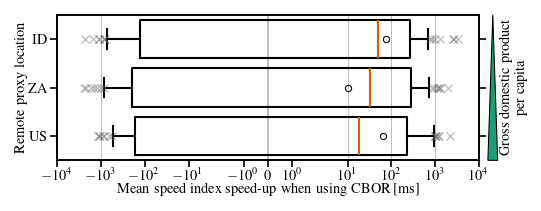

In [5]:
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 0.89,
    matplotlib.rcParams["figure.figsize"][1] * 4 / 8,
)

LOCATIONS = {
    "us-west": "US",
    "indonesia": "ID",
    "africa-south": "ZA",
}
LOCATIONS_SORTED = [
    "us-west",
    "africa-south",
    "indonesia",
]
ZSCORE_THRESHOLD = 5

df = polars.read_parquet(EVALUATION_DIR / "output-dataset" / "lighthouse.parquet")

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()

speed_index = df.filter(~polars.col("packed")).select(
    ["extra", "compress", "domain", "run", "speed_index"]
).pivot(
    "compress",
    index=["extra", "domain", "run"],
    values="speed_index",
).with_columns(
    **{
        # ~compressed - compressed
        "speed_index": polars.col(f"false") - polars.col(f"true")
    }
).filter(
    polars.col("speed_index").is_not_null()
).select(["extra", "domain", "run", "speed_index"]).pivot(
    "extra",
    index=["domain", "run"],
    values="speed_index",
).with_columns(
    **{
        f"z-score-{l}": ((polars.col(l) - polars.col(l).mean()) / polars.col(l).std()).abs()
        for l in LOCATIONS_SORTED
    }
)

runs = {
    k: speed_index.select([k, "domain", "run"]).filter(polars.col(k).is_not_null()).group_by(["domain"]).agg(polars.col("run").unique().len())["run"].max()
    for k in LOCATIONS_SORTED
}
domains_per_run = {
    k: speed_index.select([k, "domain", "run"]).filter(polars.col(k).is_not_null()).group_by(["run"]).agg(polars.col("domain").unique().len())["domain"].mean()
    for k in LOCATIONS_SORTED
}
speed_index_var = speed_index.group_by("domain").agg(
    *[
        polars.col(k).var()
        for k in LOCATIONS_SORTED 
    ],
    *[
        polars.col(k).mean().alias(f"{k}-mean")
        for k in LOCATIONS_SORTED 
    ]
).with_columns(
    **{
        f"{k}-var-norm": polars.col(k) / polars.col(k).max() * 0.45
        for k in LOCATIONS_SORTED 
    }
)
#speed_index = speed_index.group_by("domain").mean()

stats_list = []

for loc in LOCATIONS_SORTED:
    values = speed_index.filter(
        polars.col(loc).is_not_null()
        & (polars.col(f"z-score-{loc}") <= ZSCORE_THRESHOLD)
    ).group_by("domain").mean()
    
    stats_list.append(
        {
            "location": LOCATIONS[loc],
            "runs": runs[loc],
            # some websites do not load every time, so count the websites fractionally, based on the successful runs with
            # this webside
            "successful domains per run": domains_per_run[loc],
            "successful domains": values["domain"].unique().len(),
            "min.": values[loc].min(),
            "max.": values[loc].max(),
            "mean": values[loc].mean(),
            "std.": values[loc].std(),
            "q05": values[loc].quantile(0.05),
            "q25": values[loc].quantile(0.25),
            "median": values[loc].median(),
            "q75": values[loc].quantile(0.75),
            "q95": values[loc].quantile(0.95),
        }
    )

stats = polars.DataFrame(stats_list)

with polars.Config(float_precision=1):
    display(stats)
        
ax.boxplot(
    [
        speed_index.filter(
            polars.col(l).is_not_null()
            & (polars.col(f"z-score-{l}") <= ZSCORE_THRESHOLD)
        ).group_by("domain").mean()[l].to_numpy()
        for l in LOCATIONS_SORTED
    ],
    positions=range(len(LOCATIONS_SORTED)),
    widths=0.8,
    whis=(5, 95),
    showfliers=True,
    showmeans=True,
    meanprops={"marker": ".", "markeredgecolor": "black", "markerfacecolor": "none"},
    flierprops={
        "marker": "x",
        "markersize": 4,
        "markeredgecolor": matplotlib.colormaps["Dark2"].colors[7],
        "markerfacecolor": "none",
        "markeredgewidth": 0.5,
        "alpha": 0.5,
    },
    medianprops={"c": matplotlib.colormaps["Dark2"].colors[1]},
    vert=False,
)
ax.set_axisbelow(True)
#ax.grid(axis="x")
ax.axvline(-1e3, ymin=-0.5, ymax=2.5, linewidth=0.5, color="gray", zorder=-100, alpha=0.5)
ax.axvline(0, ymin=-0.5, ymax=2.5, linewidth=1, color="gray", zorder=-100, alpha=0.5)
ax.axvline(1e1, ymin=-0.5, ymax=2.5, linewidth=0.5, color="gray", zorder=-100, alpha=0.5)
ax.axvline(1e2, ymin=-0.5, ymax=2.5, linewidth=0.5, color="gray", zorder=-100, alpha=0.5)
ax.axvline(1e3, ymin=-0.5, ymax=2.5, linewidth=0.5, color="gray", zorder=-100, alpha=0.5)
ax.set_xlabel(f"Mean speed index speed-up when using CBOR [ms]")
ax.set_xlim(-10000, 10000)
ax.set_xscale("symlog")

ax.set_ylim(-0.5, 2.5)
ax.set_ylabel(f"Remote proxy location")
ax.set_yticks(range(len(LOCATIONS_SORTED)), [LOCATIONS[l] for l in LOCATIONS_SORTED])
ax2 = ax.twinx()
ax2.set_ylim(-0.5, 2.5)
ax2.set_ylabel("Gross domestic product\nper capita", labelpad=5)
ax2.set_yticks(range(len(LOCATIONS_SORTED)), [])

line = matplotlib.patches.Polygon(
    [
        (0.916, 0.11),
        (0.925, 0.88),
        (0.934, 0.11),
    ],
    transform=fig.transFigure,
    edgecolor="black",
    facecolor=matplotlib.colormaps["Dark2"].colors[0],
    linewidth=0.5,
)
fig.add_artist(line)

filepath = EVALUATION_DIR / "plots" / f"lighthouse-box-speed-index.pdf"
display(
    Markdown(
        f"## [Lighthouse Metrics (Box Plot, Speed-Index only)]({str(filepath.relative_to(pathlib.Path.cwd()))})"
    )
)
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()

## Standard Deviation Decrease Due to More Runs

### [Run Standard Deviation](06_e2e_eval/plots/lighthouse-run-var.pdf)

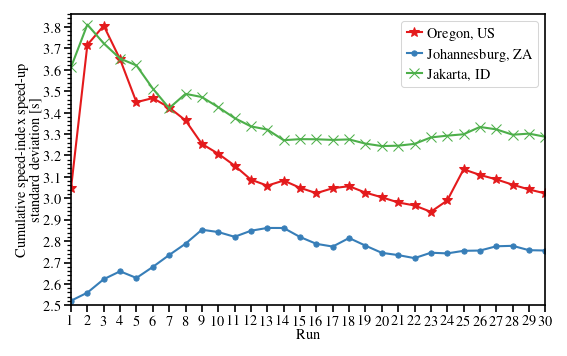

In [6]:
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.0,
    matplotlib.rcParams["figure.figsize"][1] * 8 / 8,
)
LOCATIONS = {
    "us-west": "Oregon, US",
    "indonesia": "Jakarta, ID",
    "africa-south": "Johannesburg, ZA",
}
LOCATIONS_SORTED = [
    "us-west",
    "africa-south",
    "indonesia",
]
METRICS = [
    "first_contentful_paint",
    "largest_contentful_paint",
    "speed_index",
    "total_blocking_time",
    "cumulative_layout_shift",
    "rtt",
]
ZSCORE_THRESHOLD = 5

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()
ax.set_prop_cycle(color=matplotlib.colormaps["Set1"].colors[:3], marker=["*", ".", "x"])

for location in LOCATIONS_SORTED:
    times = df.filter(~polars.col("packed") & (polars.col("extra") == location)).select(
        ["compress", "domain", "run"] + METRICS
    ).pivot(
        "compress",
        index=["domain", "run"],
        values=METRICS,
    ).with_columns(
        **{
            # ~compressed - compressed and convert to seconds
            k: (polars.col(f"{k}_false") - polars.col(f"{k}_true")) / 1000
            for k in METRICS
        }
    ).with_columns(
        **{
            f"z-score-{k}": ((polars.col(k) - polars.col(k).mean()) / polars.col(k).std()).abs()
            for k in METRICS
        }
    ).filter(
        polars.col("first_contentful_paint").is_not_null()
        & polars.col("largest_contentful_paint").is_not_null()
        & polars.col("speed_index").is_not_null()
        & polars.col("total_blocking_time").is_not_null()
        & polars.col("cumulative_layout_shift").is_not_null()
        & polars.col("rtt").is_not_null()
    ).select(["domain", "run"] + METRICS + [f"z-score-{k}" for k in METRICS])

    stds = None
    for run in range(1, times["run"].max() + 1):
        # if location == "us-west":
        #     if run == 2:
        #         # this run had an unusually high variance which was
        #         # nearly one order of magnitude greater in speed_index 
        #         # (~92 s²), so we discarded it
        #         continue
        if location == "africa-south" and run <= 3:
            # we did not capture the remote proxy logs for those
            continue
        std = times.filter(
            (polars.col("run") <= run)
            & (polars.col("z-score-speed_index") <= ZSCORE_THRESHOLD)
        ).std().with_columns(
            runs=polars.lit(run - 3 if location == "africa-south" else run) # if location != "us-west" or run == 1 else run - 1)
            #runs=polars.lit(run if location != "us-west" or run == 1 else run - 1)
        ).select(["runs"] + METRICS)

        if stds is None:
            stds = std
        else:
            stds = polars.concat(
                [stds, std],
            )
    ax.plot(
        stds["runs"],
        stds["speed_index"], 
        label=LOCATIONS[location],
        markersize=5,
    )
ax.set_xlabel("Run")
ax.set_xlim(1, 30)
ax.set_xticks(numpy.arange(1, 31))
ax.set_ylabel("Cumulative speed-index speed-up\nstandard deviation [s]")
ax.set_ylim(2.5, 3.86)
ax.set_yticks(numpy.arange(2.5, 3.87, 0.1))
ax.set_yticks(numpy.arange(2.5, 3.87, 0.02), minor=True)
# ax.set_ylim(8, 78)
# ax.set_yticks(numpy.arange(10, 79, 10))
# ax.set_yticks(numpy.arange(8, 79, 1), minor=True)
ax.legend()
filepath = EVALUATION_DIR / "plots" / "lighthouse-run-var.pdf"
display(
    Markdown(
        f"### [Run Standard Deviation]({str(filepath.relative_to(pathlib.Path.cwd()))})"
    )
)
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()

# Remote Host Statistics

In [7]:
output_path = EVALUATION_DIR / "output-dataset"

with subprocess.Popen(
r"""
grep -e '\<LIGHTHOUSE_LOG_EXTRA\>' -e '\<PROXY_REMOTE_HOST\>' ${OUTPUT_PATH}/docker-compose-local-*.log | \
    sed -E -e 's/.*LIGHTHOUSE_LOG_EXTRA=-([a-z-]+).*PROXY_REMOTE_HOST=([0-9.]+) .*/\1 \2/g' \
           -e 's/.*PROXY_REMOTE_HOST=([0-9.]+) .*LIGHTHOUSE_LOG_EXTRA=-([a-z-]+).*/\2 \1/g' | sort -u | \
        while read extra addr; do
            if ! echo "${addr}" | grep -Eq "^[0-9]+.[0-9]+.[0-9]+.[0-9]+$"; then
                continue
            fi
            grep -h -E "^ *[0-9]+( +\*)*.* +\(${addr}\)( +\*| +[0-9.]+ *ms)*" ${OUTPUT_PATH}/traceroute-*.log | tr -d '\r' | \
            while read hostline; do 
                hops="$(echo "${hostline}" | grep -oE '^[0-9]+')";
                echo "${hostline}" | grep -oE '\<[0-9.]+ *ms\>' | grep -oE '\<[0-9.]+\>' | while read rtt; do
                    echo "${extra} ${addr} ${hops} ${rtt}";
                done;
            done;
        done
""",
    env={"PATH": os.environ["PATH"], "OUTPUT_PATH": str(output_path)},
    stdout=subprocess.PIPE,
    shell=True,
) as proc:
    lf = polars.scan_csv(
        proc.stdout,
        separator=" ",
        has_header=False,
        new_columns=["location", "addr", "hops", "rtt"],
    )

    with polars.Config(float_precision=0):
        display(
            lf.group_by("location").agg(
                polars.col("hops").min().alias("hops min"),
                polars.col("hops").mean().alias("hops mean"),
                polars.col("hops").std().alias("hops std"),
                polars.col("hops").max().alias("hops max"),
                polars.col("rtt").min().alias("rtt min"),
                polars.col("rtt").mean().alias("rtt mean"),
                polars.col("rtt").std().alias("rtt std"),
                polars.col("rtt").max().alias("rtt max"),
            ).sort("location").collect()
        )

location,hops min,hops mean,hops std,hops max,rtt min,rtt mean,rtt std,rtt max
str,i64,f64,f64,i64,f64,f64,f64,f64
"""africa-south""",9,16,2,18,172,176,3,188
"""indonesia""",20,20,0,21,189,253,23,271
"""us-west""",14,15,1,30,153,163,8,179


# Analyze Lighthouse Errors

In [8]:
errors = df.filter(
    polars.col("error").is_not_null()
).select(
    ["domain", "run", "extra", "compress", "error"]
).with_columns(
    run=polars.when(
        polars.col("extra") != "africa-south"
    ).then(
        polars.col("run")
    ).otherwise(
        polars.col("run") - 3
    ),
)
display(Markdown("## Full Error Listing"))
with polars.Config(fmt_str_lengths=df["error"].str.len_chars().max(), tbl_rows=572):
    display(
        errors.pivot(
            "run",
            index=["domain", "compress", "extra"],
            values="error"
        ).rename(
            {
                str(k): f"run_{k:02d}"
                for k in range(1, errors["run"].max() + 1)
            }
        ).lazy().join(
            polars.scan_csv(EVALUATION_DIR / "tranco_3QL4L.csv", has_header=False, new_columns=["rank", "domain"]),
            on="domain",
        ).select(
            ["rank", "domain", "extra", "compress"] + [f"run_{k:02d}" for k in range(1, errors["run"].max() + 1)]
        ).sort(["rank", "extra", "compress"]).collect()
    )
display(Markdown("## Error Summary"))
error_summary = errors.group_by("error").agg(
    polars.col("error").len().alias("count"),
).with_columns(
    polars.col("error").str.replace(
        r"ERRORED_DOCUMENT_REQUEST \(Status: ([0-9]+)\)", "${1}"
    ).map_elements(
        lambda x: (
            f"HTTP error: {http.HTTPStatus(int(x)).phrase} ({x})"
            if int(x) in http.HTTPStatus
            else f"HTTP error: CDN Connection Timed Out ({x})"
        ) if x.isdigit() else x,
        return_dtype=polars.String,
    )
).with_columns(
    error_ratio=(polars.col("count") / df["domain"].len())
)
error_summary = polars.concat(
    [
        error_summary,
        polars.DataFrame([{"error": "No audit error", "count": None, "error_ratio": 1.0 - error_summary["error_ratio"].sum()}])
    ]
).sort("error_ratio")
with polars.Config(fmt_str_lengths=error_summary["error"].str.len_chars().max(), float_precision=3, tbl_rows=20):
    display(error_summary)
    display(error_summary.filter(polars.col("error").str.starts_with("HTTP error:")).sum().with_columns(error=polars.lit("HTTP error")))
    display(
        error_summary.filter(
            ~polars.col("error").str.starts_with("HTTP error:")
            & (polars.col("error") != "CHROME_INTERSTITIAL_ERROR")
            & (polars.col("error") != "NO_FCP")
            & (polars.col("error") != "No audit error")
        ).sum().with_columns(error=polars.lit("Other errors"))
    )

## Full Error Listing

rank,domain,extra,compress,run_01,run_02,run_03,run_04,run_05,run_06,run_07,run_08,run_09,run_10,run_11,run_12,run_13,run_14,run_15,run_16,run_17,run_18,run_19,run_20,run_21,run_22,run_23,run_24,run_25,run_26,run_27,run_28,run_29,run_30
i64,str,str,bool,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
2,"""gtld-servers.net""","""africa-south""",false,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR"""
2,"""gtld-servers.net""","""africa-south""",true,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR"""
2,"""gtld-servers.net""","""indonesia""",false,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR"""
2,"""gtld-servers.net""","""indonesia""",true,"""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_INTERSTITIAL_ERROR""","""CHROME_

## Error Summary

error,count,error_ratio
str,u64,f64
"""HTTP error: CDN Connection Timed Out (521)""",1,0.000
"""HTTP error: Service Unavailable (503)""",2,0.000
"""NO_NAVSTART""",2,0.000
"""HTTP error: Too Many Requests (429)""",2,0.000
"""HTTP error: Internal Server Error (500)""",4,0.000
"""HTTP error: CDN Connection Timed Out (522)""",4,0.000
"""PAGE_HUNG""",10,0.000
"""HTTP error: Unavailable For Legal Reasons (451)""",60,0.002
"""NOT_HTML""",180,0.005


error,count,error_ratio
str,u64,f64
"""HTTP error""",4572,0.127


error,count,error_ratio
str,u64,f64
"""Other errors""",192,0.005


# Review Current Experiment Progress

In [9]:
lf = df.select(["domain", "extra", "run", "error"]).group_by(["domain", "extra"]).agg(polars.col("run").len().alias("runs"), polars.col("error")).with_columns(
    polars.col("runs") / 2   # compressed and uncompressed runs are counted here together so devide by 2
).lazy().join(
    polars.scan_csv(EVALUATION_DIR / "tranco_3QL4L.csv", has_header=False, new_columns=["rank", "domain"]),
    on="domain",
).sort(["rank", "extra"]).select(["rank", "domain", "extra", "runs", "error"])
with polars.Config(tbl_rows=df.shape[0]):
    display(lf.collect())

rank,domain,extra,runs,error
i64,str,str,f64,list[str]
1,"""google.com""","""africa-south""",30.0,"[null, null, … null]"
1,"""google.com""","""indonesia""",30.0,"[null, null, … null]"
1,"""google.com""","""us-west""",30.0,"[null, null, … null]"
2,"""gtld-servers.net""","""africa-south""",30.0,"[""CHROME_INTERSTITIAL_ERROR"", ""CHROME_INTERSTITIAL_ERROR"", … ""CHROME_INTERSTITIAL_ERROR""]"
2,"""gtld-servers.net""","""indonesia""",30.0,"[""CHROME_INTERSTITIAL_ERROR"", ""CHROME_INTERSTITIAL_ERROR"", … ""CHROME_INTERSTITIAL_ERROR""]"
2,"""gtld-servers.net""","""us-west""",30.0,"[""CHROME_INTERSTITIAL_ERROR"", ""CHROME_INTERSTITIAL_ERROR"", … ""CHROME_INTERSTITIAL_ERROR""]"
3,"""gstatic.com""","""africa-south""",30.0,"[""ERRORED_DOCUMENT_REQUEST (Status: 404)"", ""ERRORED_DOCUMENT_REQUEST (Status: 404)"", … ""ERRORED_DOCUMENT_REQUEST (Status: 404)""]"
3,"""gstatic.com""","""indonesia""",30.0,"[""ERRORED_DOCUMENT_REQUEST (Status: 404)"", ""ERRORED_DOCUMENT_REQUEST (Status: 404)"", … ""ERRORED_DOCUMENT_REQUEST (Status: 404)""]"
3,"""gstatic.com""","""us-west""",30.0,"[""ERRORED_DOCUMENT_REQUEST (Status: 404)"", ""ERRORED_DOCUMENT_REQUEST (Status: 404)"", … ""ERRORED_DOCUMENT_REQUEST (Status: 404)""]"


# Extract Proxy Logs

In [10]:
output_path = EVALUATION_DIR / "output-dataset"

lhtss = polars.scan_parquet(
    EVALUATION_DIR / "output-dataset" / "lighthouse.parquet"
).select(["lighthouse_timestamp", "extra"]).unique().rename(
    {
        "lighthouse_timestamp": "lhts",
        "extra": "location",
    }
)

for proxy in ["local", "remote"]:
    with subprocess.Popen(
        "awk -F'\t' 'BEGIN { OFS=FS } "
        "$1 ~ /ROW/ || $1 ~ /marker/ {"
        "  if ($1 ~ /marker/) {"
        "    print \"logfile\", $0"
        "  } else {"
        "    print FILENAME, $0"
        "  }"
        #"}' \"${OUTPUT_PATH}/docker-compose-local-1779344276.log\" "r"| tr -d '\f\r\v'",
        "}' \"${OUTPUT_PATH}/"f"docker-compose-{proxy}-\"*.log "r"| tr -d '\f\r\v'",
        stdout=subprocess.PIPE,
        env={"PATH": os.environ["PATH"], "OUTPUT_PATH": str(output_path)},
        shell=True,
    ) as proc:
        polars.scan_csv(
            proc.stdout,
            separator="\t",
            infer_schema=False,  # do not infer schema as header might repeat (see filter below)
        ).select(
            polars.exclude("^.+marker$")
        ).filter(
            polars.col("timestamp") != "timestamp"  # skip header repetitions
        ).unique(
            ["logfile", "timestamp", "proxy", "flow_id", "method", "response_status"]
        ).with_columns(
            polars.from_epoch(
                polars.col("lhts").cast(polars.Int32),
                time_unit="s",
            ).dt.convert_time_zone(time_zone="Europe/Berlin"),
        ).join(
            lhtss,
            on="lhts",
        ).with_columns(
            polars.from_epoch(
                polars.col("timestamp").cast(polars.Float64)
            ).dt.convert_time_zone(time_zone="Europe/Berlin"),
            polars.col("logfile").str.split("/").list.last(),
            polars.col("domain_rank").cast(polars.Int32),
            polars.col("run").cast(polars.Int8),
            polars.col("convert").str.to_lowercase() == "true",
            polars.col("packed").str.to_lowercase() == "true",
            polars.col("response_status").cast(polars.Int16),
            polars.col("orig_body_length").cast(polars.Int64),
            polars.col("orig_content_length").cast(polars.Int64),
            polars.col("new_body_length").cast(polars.Int64),
            polars.col("query_missing").str.to_lowercase() == "true",
            polars.col("handler_time").cast(polars.Float64),
        ).select(
            polars.col("logfile"),
            polars.col("timestamp"),
            polars.col("location"),
            polars.exclude(["logfile", "timestamp", "location"])
        ).sort("timestamp").sink_parquet(
            EVALUATION_DIR / "output-dataset" / f"mitmproxy-{proxy}.parquet",
            compression="zstd",
            compression_level=22,
        )

# Analyze Handler Times

location,convert,proxy,runs
str,bool,str,f64
"""africa-south""",false,"""local""",29.985
"""africa-south""",false,"""remote""",29.68
"""africa-south""",true,"""local""",29.995
"""africa-south""",true,"""remote""",29.86
"""indonesia""",false,"""local""",30.0
"""indonesia""",false,"""remote""",29.99
"""indonesia""",true,"""local""",30.0
"""indonesia""",true,"""remote""",29.995
"""us-west""",false,"""local""",29.995


location,proxy mode,min.,max.,mean,std.,q1,median,q3
str,str,f64,f64,f64,f64,f64,f64,f64
"""Oregon, US""","""Not converted""",0.000292,1.694617,0.108528,0.155744,0.008442,0.048342,0.145411
"""Oregon, US""","""Converted""",0.000279,6.002697,0.134992,0.211955,0.010718,0.057564,0.177532
"""Oregon, US""","""Difference""",-0.000012,4.308079,0.026464,0.056211,0.002276,0.009222,0.032121


location,proxy mode,min.,max.,mean,std.,q1,median,q3
str,str,f64,f64,f64,f64,f64,f64,f64
"""Johannesburg, ZA""","""Not converted""",0.000253,1.867506,0.077744,0.108422,0.006524,0.033166,0.113754
"""Johannesburg, ZA""","""Converted""",0.00026,3.514723,0.097699,0.143228,0.007966,0.040349,0.139528
"""Johannesburg, ZA""","""Difference""",0.000007,1.647217,0.019956,0.034806,0.001441,0.007183,0.025774


location,proxy mode,min.,max.,mean,std.,q1,median,q3
str,str,f64,f64,f64,f64,f64,f64,f64
"""Jakarta, ID""","""Not converted""",0.000395,3.389015,0.097202,0.141704,0.008161,0.040567,0.132242
"""Jakarta, ID""","""Converted""",0.000358,3.569034,0.118063,0.173056,0.010296,0.047729,0.159011
"""Jakarta, ID""","""Difference""",-0.000036,0.180019,0.020861,0.031352,0.002134,0.007162,0.026768


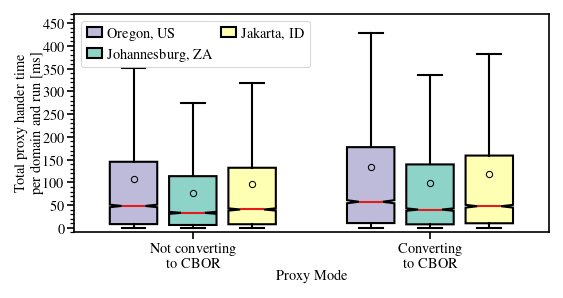

In [11]:
BOXPLOT_COLORS = {
    "africa-south": matplotlib.colormaps["Set3"].colors[0],
    "indonesia": matplotlib.colormaps["Set3"].colors[1],
    "us-west": matplotlib.colormaps["Set3"].colors[2],
}

matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.0,
    matplotlib.rcParams["figure.figsize"][1] * 6 / 8,
)

logs_df = polars.scan_parquet(
    EVALUATION_DIR / "output-dataset" / "mitmproxy-*.parquet"
).filter(
    polars.col("domain").is_not_null() & ~polars.col("packed")
).filter(
    polars.col("convert").is_not_null()
)
with polars.Config(tbl_rows=12):
    display(
        logs_df.group_by(
            ["proxy", "location", "convert", "domain"]
        ).agg(polars.col("run")).with_columns(
            polars.col("run").list.unique().list.len(),
        ).rename(
            {"run": "runs"}
        ).group_by(["proxy", "location", "convert"]).agg(
            polars.col("runs").mean()
        ).select(
            ["location", "convert", "proxy", "runs"]
        ).sort(["location", "convert", "proxy"]).collect()
    )

logs_df = logs_df.group_by(
    ["domain", "run", "location", "convert"]
).agg(
    polars.col("handler_time").sum(),
).filter(
    # we are missing some remote logs for these runs from this location
    (polars.col("location") != "africa-south") | (polars.col("run") > 3)
).collect().pivot(
    "convert",
    index=["location", "domain", "run"],
    values="handler_time",
).select(["location", "false", "true"]).rename(
    {"false": "Not converted", "true": "Converted"}
).filter(
    polars.col("Not converted").is_not_null() &
    polars.col("Converted").is_not_null()
)

LOCATIONS_SORTED = [
    "us-west",
    "africa-south",
    "indonesia",
]
LOCATIONS = {
    "us-west": "Oregon, US",
    "indonesia": "Jakarta, ID",
    "africa-south": "Johannesburg, ZA",
}
LOCATION_OFFSET = {
    "us-west": -0.25,
    "africa-south": 0,
    "indonesia": 0.25,
}
WIDTH = 0.3

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()

for location in LOCATIONS_SORTED:
    data = logs_df.filter(
        polars.col("location") == location
    ).select(["Not converted", "Converted"])
    stats = polars.DataFrame(
        [
            {
                "location": LOCATIONS[location],
                "proxy mode": m,
                "min.": data[m].min(),
                "max.": data[m].max(),
                "mean": data[m].mean(),
                "std.": data[m].std(),
                "q1": data[m].quantile(0.25),
                "median": data[m].median(),
                "q3": data[m].quantile(0.75),
            }
            for m in ["Not converted", "Converted"]
        ] + [
            {
                "location": LOCATIONS[location],
                "proxy mode": "Difference",
                "min.": data["Converted"].min() - data["Not converted"].min(),
                "max.": data["Converted"].max() - data["Not converted"].max(),
                "mean": data["Converted"].mean() - data["Not converted"].mean(),
                "std.": data["Converted"].std() - data["Not converted"].std(),
                "q1": data["Converted"].quantile(0.25) - data["Not converted"].quantile(0.25),
                "median": data["Converted"].median() - data["Not converted"].median(),
                "q3": data["Converted"].quantile(0.75) - data["Not converted"].quantile(0.75),
            }
        ],
    )

    display(stats)
    bxplt = ax.boxplot(
        data,
        positions=numpy.arange(0, 2) + LOCATION_OFFSET[location],
        notch=True,
        widths=WIDTH - .1,
        showfliers=False,
        showmeans=True,
        patch_artist=True,
        label=LOCATIONS[location],
        meanprops={"marker": ".", "markeredgecolor": "black", "markerfacecolor": "none"},
        medianprops={"c": matplotlib.colormaps["Set1"].colors[0]},
    )
    for patch in bxplt['boxes']:
        patch.set_facecolor(BOXPLOT_COLORS[location])
        patch.set_linewidth(1)
ax.set_xlabel("Proxy Mode")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks(numpy.arange(0, 2), ["Not converting\nto CBOR", "Converting\nto CBOR"])
ax.set_ylabel("Total proxy hander time\nper domain and run [ms]")
ax.set_ylim(-0.01, 0.47)
ax.set_yticks(numpy.arange(0.0, 0.48, 0.05))
ax.set_yticks(numpy.arange(-0.01, 0.48, 0.01), minor=True)
ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda y, pos: f"${y * 1000.0:.0f}$"))
ax.legend(ncol=2, loc="upper left")
matplotlib.pyplot.show()

# Analyze Request/Response Make-Up

convert,reqs_count,compressed_json_reqs_ratio,json_reqs_ratio,dns_reqs_ratio,resps_count,compressed_json_resps_ratio,json_resps_ratio,dns_resps_ratio
bool,f64,f64,f64,f64,f64,f64,f64,f64
false,57653.017992,0.237143,0.0,0.0,56110.619318,3.699201,0.0,0.0
true,57523.151515,0.236318,3.769128,83.624998,56116.090909,3.683214,2.655956,92.247404


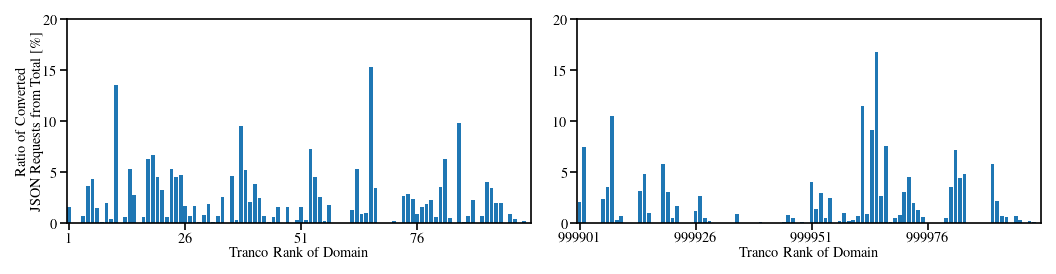

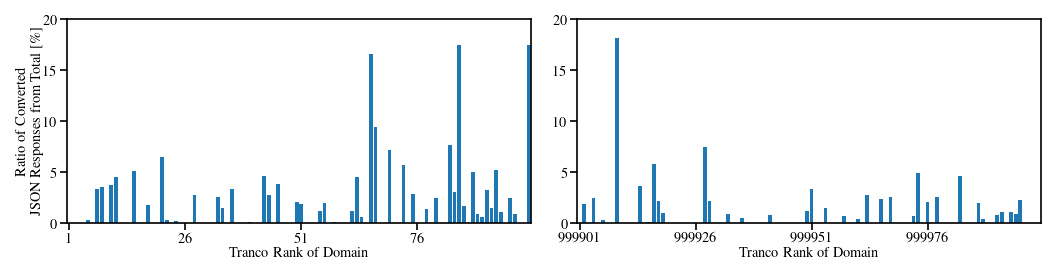

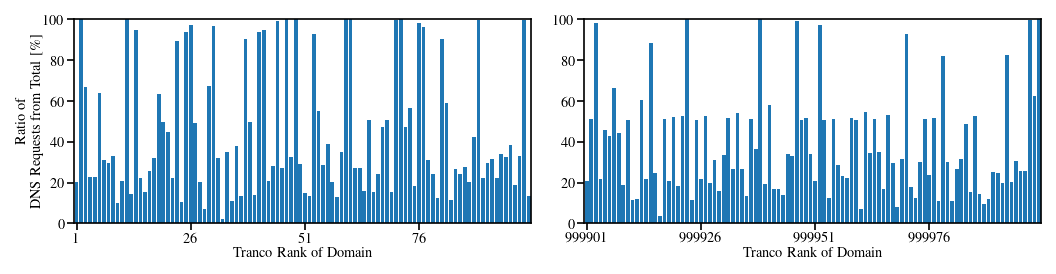

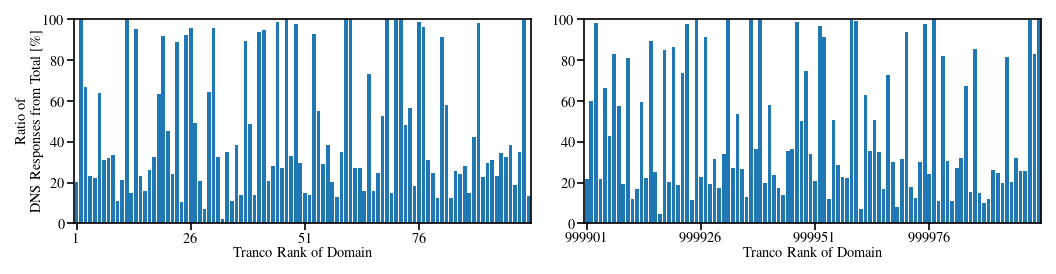

In [12]:
matplotlib.style.use(pathlib.Path.cwd() / "mlenders_fullwidth_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.0,
    matplotlib.rcParams["figure.figsize"][1] * 7 / 8,
)

logs_lf = polars.scan_parquet(
    EVALUATION_DIR / "output-dataset" / "mitmproxy-*.parquet"
).filter(polars.col("domain").is_not_null() & ~polars.col("packed")).filter(
    # we are missing some remote logs for these runs
    (polars.col("lhts") > 1777586400)
)

requests = logs_lf.filter(
    polars.col("response_status").is_null()
    & (polars.col("proxy") == "local")
    & (polars.col("msg") != "Start run")
    & (polars.col("msg") != "End run")
)
responses = logs_lf.filter(
    polars.col("response_status").is_not_null()
    & (polars.col("proxy") == "remote")
    & (polars.col("msg") != "Start run")
    & (polars.col("msg") != "End run")
)
compressed_json_reqs = requests.filter(
    polars.col("orig_content_type").str.contains("json")
    & polars.col("orig_content_encoding").is_not_null()
    & ~polars.col("msg").str.starts_with("Converted ")
)
compressed_json_resps = responses.filter(
    polars.col("orig_content_type").str.contains("json")
    & polars.col("orig_content_encoding").is_not_null()
    & ~polars.col("msg").str.starts_with("Converted ")
)
converted_reqs = requests.filter(polars.col("msg").str.starts_with("Converted "))
converted_resps = responses.filter(polars.col("msg").str.starts_with("Converted "))
converted_json_reqs = converted_reqs.filter(polars.col("msg").str.contains("JSON"))
converted_json_resps = converted_resps.filter(polars.col("msg").str.contains("JSON"))
converted_dns_reqs = converted_reqs.filter(polars.col("msg").str.contains("DNS"))
converted_dns_resps = converted_resps.filter(polars.col("msg").str.contains("DNS"))

stats_df = requests.group_by(
    ["domain", "domain_rank", "run", "convert"]
).agg(reqs_count=polars.col("msg").len()).join(
    responses.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    responses.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    compressed_json_reqs.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(compressed_json_reqs_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    compressed_json_resps.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(compressed_json_resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_reqs.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(converted_reqs_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_resps.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(converted_resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_json_reqs.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(json_reqs_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_json_resps.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(json_resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_dns_reqs.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(dns_reqs_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).join(
    converted_dns_resps.group_by(
        ["domain", "domain_rank", "run", "convert"]
    ).agg(dns_resps_count=polars.col("msg").len()),
    ["domain", "domain_rank", "run", "convert"],
    "left",
).sort(["domain_rank", "run", "convert"]).with_columns(
    polars.col("compressed_json_reqs_count").fill_null(0) / polars.col("reqs_count"),
    polars.col("compressed_json_resps_count").fill_null(0) / polars.col("resps_count"),
    polars.col("converted_reqs_count").fill_null(0) / polars.col("reqs_count"),
    polars.col("converted_resps_count").fill_null(0) / polars.col("resps_count"),
    polars.col("json_reqs_count").fill_null(0) / polars.col("reqs_count"),
    polars.col("json_resps_count").fill_null(0) / polars.col("resps_count"),
    polars.col("dns_reqs_count").fill_null(0) / polars.col("reqs_count"),
    polars.col("dns_resps_count").fill_null(0) / polars.col("resps_count"),
).rename(
    {
        "compressed_json_reqs_count": "compressed_json_reqs_ratio",
        "compressed_json_resps_count": "compressed_json_resps_ratio",
        "converted_reqs_count": "converted_reqs_ratio",
        "converted_resps_count": "converted_resps_ratio",
        "json_reqs_count": "json_reqs_ratio",
        "json_resps_count": "json_resps_ratio",
        "dns_reqs_count": "dns_reqs_ratio",
        "dns_resps_count": "dns_resps_ratio",
    }
).group_by(
    ["domain", "domain_rank", "convert"]
).mean().select(polars.exclude("run")).sort(["domain_rank", "convert"]).collect()

msg_diff = stats_df.filter(polars.col("convert")).select(
    ["domain", "domain_rank", "reqs_count", "resps_count"]
).join(
    stats_df.filter(~polars.col("convert")).select(
        ["domain", "domain_rank", "reqs_count", "resps_count"]
    ),
    ["domain", "domain_rank"],
    "right",
).with_columns(
    reqs_diff=polars.col("reqs_count") - polars.col("reqs_count_right"),
    resps_diff=polars.col("resps_count") - polars.col("resps_count_right"),
)
HUMAN = {
    "reqs": "Requests",
    "resps": "Responses",
}

display(
    stats_df.group_by("convert").agg(
        *[
            polars.col(c).sum()
            for c in [
                "reqs_count",
                "compressed_json_reqs_ratio",
                "json_reqs_ratio",
                "dns_reqs_ratio",
                "resps_count",
                "compressed_json_resps_ratio",
                "json_resps_ratio",
                "dns_resps_ratio",
            ]
        ]
    )
)

stats_df = stats_df.filter(polars.col("convert") == True)

for msg in ["reqs", "resps"]:
    fig, axs = matplotlib.pyplot.subplots(ncols=2)
    fig.set_dpi(150)
    for i, (filt, ax) in enumerate(zip((polars.col("domain_rank") <= 100, polars.col("domain_rank") > 100), axs)):
        ax.bar(stats_df.filter(filt)["domain_rank"], stats_df.filter(filt)[f"json_{msg}_ratio"])
        ax.set_xlim(stats_df.filter(filt)["domain_rank"].min() - 0.5, stats_df.filter(filt)["domain_rank"].max() + 0.5)
        ax.set_xticks(
            numpy.arange(
                stats_df.filter(filt)["domain_rank"].min(),
                stats_df.filter(filt)["domain_rank"].max() + 1,
                25,
            )
        )
        ax.set_xlabel("Tranco Rank of Domain")
        ax.set_ylim(0, 0.2)
        ax.ticklabel_format(useOffset=False)
        ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        if i == 0:
            ax.set_ylabel("Ratio of Converted\n"fr"JSON {HUMAN[msg]} from Total [\%]")
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:.0f}$"))
    fig.tight_layout()
    matplotlib.pyplot.show()


for msg in ["reqs", "resps"]:
    fig, axs = matplotlib.pyplot.subplots(ncols=2)
    fig.set_dpi(150)
    for i, (filt, ax) in enumerate(zip((polars.col("domain_rank") <= 100, polars.col("domain_rank") > 100), axs)):
        ax.bar(stats_df.filter(filt)["domain_rank"], stats_df.filter(filt)[f"dns_{msg}_ratio"])
        ax.set_xlim(stats_df.filter(filt)["domain_rank"].min() - 0.5, stats_df.filter(filt)["domain_rank"].max() + 0.5)
        ax.set_xticks(
            numpy.arange(
                stats_df.filter(filt)["domain_rank"].min(),
                stats_df.filter(filt)["domain_rank"].max() + 1,
                25,
            )
        )
        ax.set_xlabel("Tranco Rank of Domain")
        ax.set_ylim(0, 1)
        ax.ticklabel_format(useOffset=False)
        ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        if i == 0:
            ax.set_ylabel("Ratio of\n "fr"DNS {HUMAN[msg]} from Total [\%]")
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x * 100:.0f}$"))
    fig.tight_layout()
    matplotlib.pyplot.show()

domain,domain_rank,reqs_byte_savings,resps_byte_savings
str,i32,f64,f64
"""bing.com""",35,4652.0,null


domain,domain_rank,reqs_byte_savings,resps_byte_savings
str,i32,f64,f64
"""apple.com""",10,46.514286,1740.707865
"""netflix.com""",36,620.684543,1823.279736
"""digicert.com""",43,46.728507,3436.923139
"""wordpress.org""",44,46.0,12402.8
"""myfritz.net""",83,60.762712,2576.588889
…,…,…,…
"""sportklub.rs""",999929,128.589474,1835.334322
"""optikon.gr""",999936,null,6139.0
"""trans.ru""",999968,761.428571,2455.847176


reqs_byte_savings,resps_byte_savings,byte_savings
f64,f64,f64
30815.492016,69571.968999,79053.589348


reqs_byte_savings,resps_byte_savings,byte_savings
f64,f64,f64
187.899342,818.493753,1026.669992


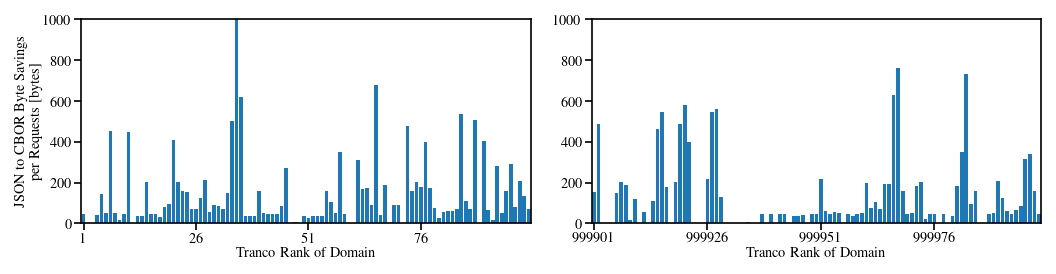

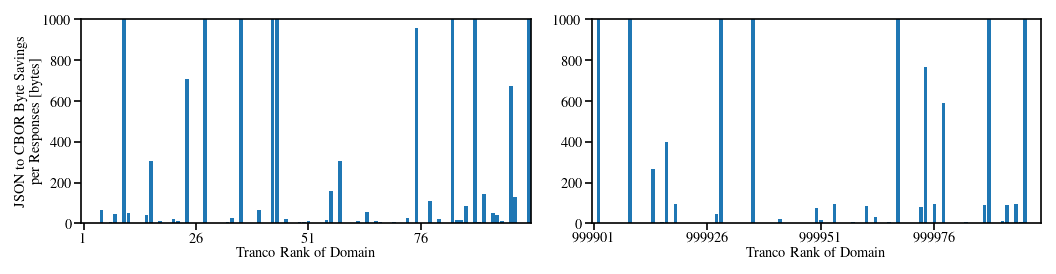

In [13]:
json_byte_savings = converted_json_reqs.with_columns(
    byte_savings=polars.col("orig_body_length") - polars.col("new_body_length"),
).group_by(
    ["domain", "domain_rank"]
).agg(polars.col("byte_savings").mean().alias("reqs_byte_savings")).join(
    converted_json_resps.with_columns(
        byte_savings=polars.col("orig_body_length") - polars.col("new_body_length"),
    ).group_by(
        ["domain", "domain_rank"]
    ).agg(polars.col("byte_savings").mean().alias("resps_byte_savings")),
    ["domain", "domain_rank"],
    "full"
).with_columns(
    domain_rank=polars.when(
        polars.col("domain_rank").is_null()
    ).then(
        polars.col("domain_rank_right")
    ).otherwise(
        polars.col("domain_rank")
    ),
    domain=polars.when(
        polars.col("domain").is_null()
    ).then(
        polars.col("domain_right")
    ).otherwise(
        polars.col("domain")
    ),
).select(polars.exclude("^.*_right$")).sort("domain_rank").collect()
display(json_byte_savings.filter(polars.col("reqs_byte_savings") > 1500))
display(json_byte_savings.filter(polars.col("resps_byte_savings") > 1500))
display(
    json_byte_savings.with_columns(
        byte_savings=polars.col("reqs_byte_savings") + polars.col("resps_byte_savings")
    ).select(
        [
            polars.col("reqs_byte_savings").sum(),
            polars.col("resps_byte_savings").sum(),
            polars.col("byte_savings").sum(),
        ],
    )
)
display(
    json_byte_savings.with_columns(
        byte_savings=polars.col("reqs_byte_savings") + polars.col("resps_byte_savings")
    ).select(
        [
            polars.col("reqs_byte_savings").mean(),
            polars.col("resps_byte_savings").mean(),
            polars.col("byte_savings").mean(),
        ]
    )
)


for msg in ["reqs", "resps"]:
    fig, axs = matplotlib.pyplot.subplots(ncols=2)
    fig.set_dpi(150)
    for i, (filt, ax) in enumerate(zip((polars.col("domain_rank") <= 100, polars.col("domain_rank") > 100), axs)):
        ax.bar(json_byte_savings.filter(filt)["domain_rank"], json_byte_savings.filter(filt)[f"{msg}_byte_savings"])
        ax.set_xlim(json_byte_savings.filter(filt)["domain_rank"].min() - 0.5, json_byte_savings.filter(filt)["domain_rank"].max() + 0.5)
        ax.set_xticks(
            numpy.arange(
                json_byte_savings.filter(filt)["domain_rank"].min(),
                json_byte_savings.filter(filt)["domain_rank"].max() + 1,
                25,
            )
        )
        ax.set_xlabel("Tranco Rank of Domain")
        ax.set_ylim(0, 1000)
        ax.ticklabel_format(useOffset=False)
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        if i == 0:
            ax.set_ylabel("JSON to CBOR Byte Savings\n"f"per {HUMAN[msg]} [bytes]")
    fig.tight_layout()
    matplotlib.pyplot.show()

reqs_byte_savings,resps_byte_savings,byte_savings
f64,f64,f64
2904.16138,8497.360544,11401.521924


reqs_byte_savings,resps_byte_savings,byte_savings
f64,f64,f64
14.520807,42.486803,57.00761


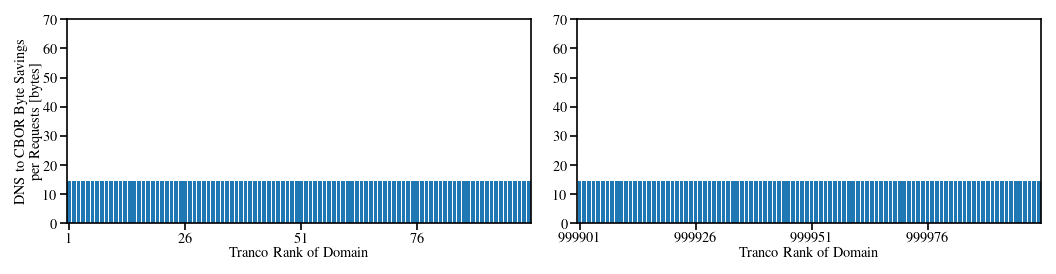

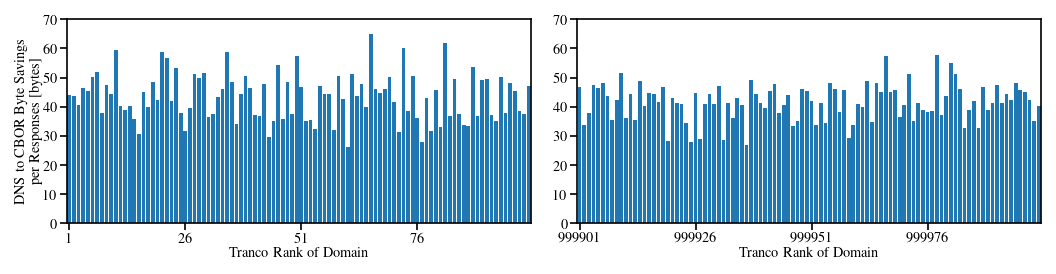

In [14]:
dns_byte_savings = converted_dns_reqs.with_columns(
    byte_savings=polars.col("orig_body_length") - polars.col("new_body_length"),
).group_by(
    ["domain", "domain_rank"]
).agg(polars.col("byte_savings").mean().alias("reqs_byte_savings")).join(
    converted_dns_resps.with_columns(
        byte_savings=polars.col("orig_body_length") - polars.col("new_body_length"),
    ).group_by(
        ["domain", "domain_rank"]
    ).agg(polars.col("byte_savings").mean().alias("resps_byte_savings")),
    ["domain", "domain_rank"],
    "full"
).with_columns(
    domain_rank=polars.when(
        polars.col("domain_rank").is_null()
    ).then(
        polars.col("domain_rank_right")
    ).otherwise(
        polars.col("domain_rank")
    ),
    domain=polars.when(
        polars.col("domain").is_null()
    ).then(
        polars.col("domain_right")
    ).otherwise(
        polars.col("domain")
    ),
).select(polars.exclude("^.*_right$")).sort("domain_rank").collect()

display(
    dns_byte_savings.with_columns(
        byte_savings=polars.col("reqs_byte_savings") + polars.col("resps_byte_savings")
    ).select(
        [
            polars.col("reqs_byte_savings").sum(),
            polars.col("resps_byte_savings").sum(),
            polars.col("byte_savings").sum(),
        ],
    )
)
display(
    dns_byte_savings.with_columns(
        byte_savings=polars.col("reqs_byte_savings") + polars.col("resps_byte_savings")
    ).select(
        [
            polars.col("reqs_byte_savings").mean(),
            polars.col("resps_byte_savings").mean(),
            polars.col("byte_savings").mean(),
        ]
    )
)

for msg in ["reqs", "resps"]:
    fig, axs = matplotlib.pyplot.subplots(ncols=2)
    fig.set_dpi(150)
    for i, (filt, ax) in enumerate(zip((polars.col("domain_rank") <= 100, polars.col("domain_rank") > 100), axs)):
        ax.bar(dns_byte_savings.filter(filt)["domain_rank"], dns_byte_savings.filter(filt)[f"{msg}_byte_savings"])
        ax.set_xlim(dns_byte_savings.filter(filt)["domain_rank"].min() - 0.5, dns_byte_savings.filter(filt)["domain_rank"].max() + 0.5)
        ax.set_xticks(
            numpy.arange(
                dns_byte_savings.filter(filt)["domain_rank"].min(),
                dns_byte_savings.filter(filt)["domain_rank"].max() + 1,
                25,
            )
        )
        ax.set_xlabel("Tranco Rank of Domain")
        ax.set_ylim(0, 70)
        ax.ticklabel_format(useOffset=False)
        ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
        if i == 0:
            ax.set_ylabel(fr"DNS to CBOR Byte Savings""\n"f"per {HUMAN[msg]} [bytes]")
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, pos: f"${x:.0f}$"))
    fig.tight_layout()
    matplotlib.pyplot.show()

# Timestamps of Start and End of Experiments


- **Start:** 2026-05-03T13:19:09+02:00
- **End:** 2026-05-23T13:28:52+02:00

## [Lighthouse Runtimes](06_e2e_eval/plots/lighthouse-runtimes.pdf)

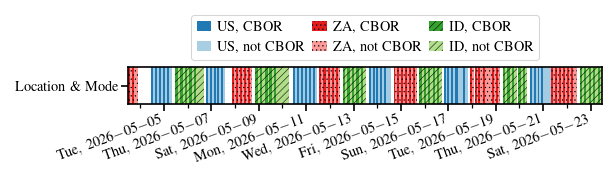

In [15]:
LOCATIONS = {
    "us-west": "US",
    "indonesia": "ID",
    "africa-south": "ZA",
}
LOCATION_COLORS = {
    ("us-west", False): matplotlib.colormaps["Paired"].colors[0],
    ("us-west", True): matplotlib.colormaps["Paired"].colors[1],
    ("indonesia", False):  matplotlib.colormaps["Paired"].colors[2],
    ("indonesia", True):  matplotlib.colormaps["Paired"].colors[3],
    ("africa-south", False):  matplotlib.colormaps["Paired"].colors[4],
    ("africa-south", True):  matplotlib.colormaps["Paired"].colors[5],
}
LOCATION_HATCH = {
    "us-west": None,
    "indonesia": "///////",
    "africa-south": r"......",
}
LOCATIONS_SORTED = [
    "us-west",
    "africa-south",
    "indonesia",
]

matplotlib.style.use(pathlib.Path.cwd() / "mlenders_column_ieeetran.mplstyle")
matplotlib.rcParams["figure.figsize"] = (
    matplotlib.rcParams["figure.figsize"][0] * 1.0,
    matplotlib.rcParams["figure.figsize"][1] * 1 / 8,
)

pxy = polars.scan_parquet(
    EVALUATION_DIR / "output-dataset" / "mitmproxy-*.parquet"
)

fig = matplotlib.pyplot.figure(
    figsize=matplotlib.rcParams["figure.figsize"],
    dpi=150,
)
ax = matplotlib.pyplot.gca()

RUNS = pxy.select("run").max().collect()["run"][0]
min_x = None
max_x = None

display(
    Markdown(f"""
- **Start:** {pxy.select("lhts").min().collect()["lhts"][0].isoformat()}
- **End:** {pxy.select("timestamp").max().collect()["timestamp"][0].isoformat()}"""
    )
)

for location in LOCATIONS_SORTED:
    for run in range(1, RUNS + 1):
        for compress in [True, False]:
            run_start = pxy.filter(
                (polars.col("location") == location)
                & (polars.col("run") == run)
                & (polars.col("convert") if compress else ~polars.col("convert"))
            ).collect()["lhts"].min()
            if run_start is None:
                continue
            if min_x is None or run_start < min_x:
                min_x = run_start
            run_end = pxy.filter(polars.col("lhts").is_not_null()).filter(
                (polars.col("location") == location)
                & (polars.col("run") == run)
                & (polars.col("lhts") >= run_start)
            ).select("timestamp").max().collect()["timestamp"][0]
            if run_end is None:
                continue
            if max_x is None or run_end > max_x:
                max_x = run_end
            ax.barh(
                0,
                left=run_start,
                width=[run_end - run_start],
                color=LOCATION_COLORS[location, compress],
                hatch=LOCATION_HATCH[location],
                height=0.8,
                alpha=.99,
            )

ax.set_xlim(min_x, max_x)
ax.xaxis.set_major_locator(matplotlib.dates.AutoDateLocator(minticks=8, maxticks=16))
ax.xaxis.set_minor_locator(matplotlib.dates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(matplotlib.dates.DateFormatter('%a, %Y-%m-%d'))
for label in ax.get_xticklabels():
    label.set_rotation(20)
    label.set_horizontalalignment('right')

ax.set_ylim(-0.4, 0.4)
ax.set_yticks([0], [r"Location \& Mode"])

handles = [
    matplotlib.patches.Patch(facecolor=LOCATION_COLORS[l, c], label=f"{LOCATIONS[l]}, {"CBOR" if c else "not CBOR"}", hatch=LOCATION_HATCH[l], alpha=.99)
    for l in LOCATIONS_SORTED
    for c in [True, False]
]
ax.legend(handles=handles, ncol=3, bbox_to_anchor=(0.5, 1), loc="lower center")
filepath = EVALUATION_DIR / "plots" / "lighthouse-runtimes.pdf"
display(
    Markdown(
        f"## [Lighthouse Runtimes]({str(filepath.relative_to(pathlib.Path.cwd()))})"
    )
)
matplotlib.pyplot.savefig(filepath, bbox_inches="tight", pad_inches=0.01)
matplotlib.pyplot.show()